# **1. Perkenalan Dataset**

Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:
1. **Sumber Dataset**: Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (Kaggle, UCI ML Repository, Open Data) atau data primer yang Anda kumpulkan sendiri.

**Studi Kasus: Prediksi Keaslian Uang Kertas (Banknote Authentication)**
Dataset ini digunakan untuk memprediksi apakah sebuah uang kertas asli (0) atau palsu (1) berdasarkan ekstraksi fitur citra (gambar) menggunakan transformasi Wavelet.

**Informasi Atribut (Fitur):**
* **variance**: Varians dari citra yang ditransformasi wavelet (numerik kontinyu).
* **skewness**: Kecondongan dari citra yang ditransformasi wavelet (numerik kontinyu).
* **curtosis**: Kurtosis dari citra yang ditransformasi wavelet (numerik kontinyu).
* **entropy**: Entropi gambar (numerik kontinyu).
* **class (Target Variable)**: Keaslian uang kertas (0 = Asli, 1 = Palsu).

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from google.colab import files

print("Seluruh library berhasil di-import!")

Seluruh library berhasil di-import!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
df = pd.read_csv('BankNote_Authentication.csv')

# Menampilkan informasi umum dataset
print(f"Dimensi Dataset: {df.shape[0]} baris, {df.shape[1]} kolom\n")
print("Informasi Tipe Data:")
print(df.info())

# Menampilkan 5 data teratas
df.head()

Dimensi Dataset: 1372 baris, 5 kolom

Informasi Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB
None


,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

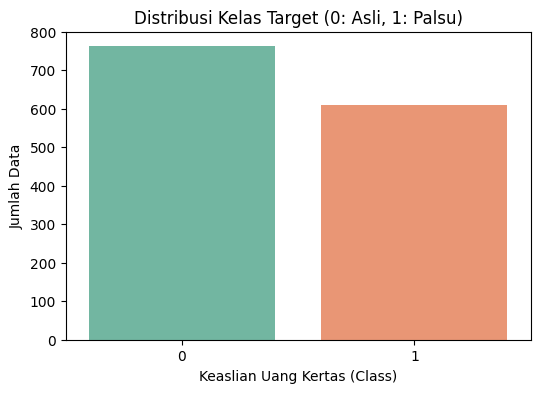

Persentase Asli (0): 55.54%
Persentase Palsu (1): 44.46%



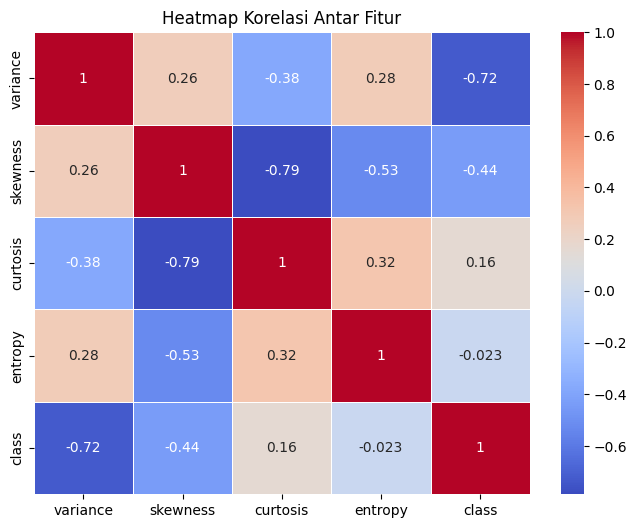

In [3]:
# Menampilkan proporsi kelas target (0: Asli, 1: Palsu)
plt.figure(figsize=(6, 4))
# Menambahkan parameter hue dan legend=False untuk mengatasi warning Seaborn
sns.countplot(x='class', data=df, hue='class', palette='Set2', legend=False)
plt.title('Distribusi Kelas Target (0: Asli, 1: Palsu)')
plt.xlabel('Keaslian Uang Kertas (Class)')
plt.ylabel('Jumlah Data')
plt.show()

# Menghitung persentase proporsi
asli = df['class'].value_counts()[0] / len(df) * 100
palsu = df['class'].value_counts()[1] / len(df) * 100
print(f"Persentase Asli (0): {asli:.2f}%")
print(f"Persentase Palsu (1): {palsu:.2f}%\n")

# Heatmap Korelasi untuk melihat hubungan antar fitur
plt.figure(figsize=(8, 6))
corr_matrix = df.corr()
# Menambahkan annot=True agar angka korelasi terlihat jelas
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
print("Memulai proses Data Preprocessing...\n")

# 1. Pengecekan Missing Values (Nilai yang hilang)
missing_values = df.isnull().sum().sum()
print(f"Jumlah total missing values: {missing_values}")

# 2. Memisahkan Fitur (X) dan Target (y)
X = df.drop(columns=['class'])
y = df['class']

# 3. Membagi dataset menjadi Train (80%) dan Test (20%)
# Menggunakan stratify=y agar proporsi kelas asli dan palsu seimbang di data latih dan uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nJumlah data latih (Train): {X_train.shape[0]} baris")
print(f"Jumlah data uji (Test): {X_test.shape[0]} baris")

# 4. Menyimpan hasil preprocessing ke dalam folder khusus
folder_path = 'banknote_preprocessing'
os.makedirs(folder_path, exist_ok=True)

# Menggabungkan X dan y kembali sebelum disimpan
train_data = X_train.copy()
train_data['class'] = y_train
test_data = X_test.copy()
test_data['class'] = y_test

train_path = f'{folder_path}/train.csv'
test_path = f'{folder_path}/test.csv'

train_data.to_csv(train_path, index=False)
test_data.to_csv(test_path, index=False)

print(f"\nBERHASIL: Data preprocessing selesai dan disimpan di dalam folder '{folder_path}'")

# 5. Mengunduh hasil secara otomatis ke komputer lokal (Untuk digunakan di MLflow)
files.download(train_path)
files.download(test_path)

Memulai proses Data Preprocessing...

Jumlah total missing values: 0

Jumlah data latih (Train): 1097 baris
Jumlah data uji (Test): 275 baris

BERHASIL: Data preprocessing selesai dan disimpan di dalam folder 'banknote_preprocessing'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>